### Install & load packages
###
using Pkg
Pkg.add(["KrylovKit", "QuantumOptics", "ITensors", 
         "ITensorMPS", "ExponentialUtilities", 
         "Plots", "LinearAlgebra", "SparseArrays", "Statistics"])

In [1]:
using LinearAlgebra
using SparseArrays
using KrylovKit
using QuantumOptics
using ExponentialUtilities
using Plots
using Statistics
println("All packages loaded")

All packages loaded ✓


###  Basic Pauli matrices & tensor products

In [3]:
I2 = [1 0; 0 1]
X  = [0 1; 1 0]
Y  = [0 -im; im 0]
Z  = [1 0; 0 -1]

commutator(A, B) = A*B - B*A

println("XY commutator check: ", commutator(X,Y) ≈ 2im*Z)
println("YZ commutator check: ", commutator(Y,Z) ≈ 2im*X)
println("ZX commutator check: ", commutator(Z,X) ≈ 2im*Y)

XY commutator check: true
YZ commutator check: true
ZX commutator check: true


### Build Heisenberg Hamiltonian

In [4]:
function heisenberg_hamiltonian(N; J=1.0, h=0.5)
    I2 = sparse([1 0; 0 1] .+ 0.0)
    Sx = sparse([0 1; 1 0] ./ 2.0)
    Sy = sparse([0 -im; im 0] ./ 2.0)
    Sz = sparse([1 0; 0 -1] ./ 2.0)

    dim = 2^N
    H   = spzeros(ComplexF64, dim, dim)

    for i in 1:N-1
        XX = foldl(kron, [j==i || j==i+1 ? Sx : I2 for j in 1:N])
        YY = foldl(kron, [j==i || j==i+1 ? Sy : I2 for j in 1:N])
        ZZ = foldl(kron, [j==i || j==i+1 ? Sz : I2 for j in 1:N])
        H += J * (XX + YY + ZZ)
    end

    for i in 1:N
        Szi = foldl(kron, [j==i ? Sz : I2 for j in 1:N])
        H  += h * Szi
    end

    return H
end

H6 = heisenberg_hamiltonian(6)
println("Hamiltonian size: ", size(H6))
println("Nonzero elements: ", nnz(H6))

Hamiltonian size: (64, 64)
Nonzero elements: 224


In [7]:
# println(H6)
display(H6)

64×64 SparseMatrixCSC{ComplexF64, Int64} with 224 stored entries:
⎡⠱⢆⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠑⠱⢆⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢄⠱⢆⢄⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠑⠱⢆⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢄⠀⠀⠱⢆⢄⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠑⢄⠀⠑⠱⢆⠑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠱⢆⢄⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⠱⢆⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠱⢆⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠑⠱⢆⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢄⠱⢆⢄⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠑⠱⢆⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠱⢆⢄⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠑⠱⢆⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠱⢆⢄⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⠱⢆⎦

### Full diagonalization vs Krylov

In [8]:
H = heisenberg_hamiltonian(6)

t1 = time_ns()
evals_full = eigvals(Hermitian(Matrix(H)))
t_full = (time_ns() - t1) / 1e6

t2 = time_ns()
evals_krylov, evecs, info = eigsolve(H, size(H,1), 4, :SR, ishermitian=true)
t_krylov = (time_ns() - t2) / 1e6

println("Full LAPACK:  ", round(t_full, digits=3), " ms")
println("Krylov:       ", round(t_krylov, digits=3), " ms")
println("Lowest 4 eigenvalues (full):   ", round.(evals_full[1:4], digits=5))
println("Lowest 4 eigenvalues (Krylov): ", round.(real.(evals_krylov[1:4]), digits=5))

Full LAPACK:  94.472 ms
Krylov:       2977.053 ms
Lowest 4 eigenvalues (full):   [-2.502, -2.49358, -2.002, -1.92146]
Lowest 4 eigenvalues (Krylov): [-2.502, -2.49358, -2.002, -1.92146]


### Scaling plot: Full vs Krylov

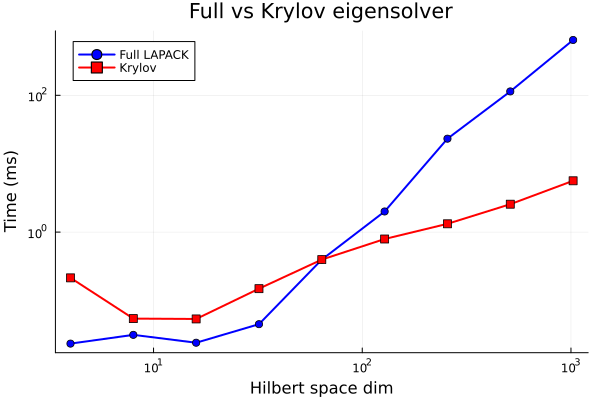

In [9]:
sizes = 2:10
t_full_list   = Float64[]
t_krylov_list = Float64[]
dims          = Int[]

for N in sizes
    H = heisenberg_hamiltonian(N)
    d = size(H, 1)
    push!(dims, d)

    t1 = time_ns()
    eigvals(Hermitian(Matrix(H)))
    push!(t_full_list, (time_ns() - t1) / 1e6)

    t2 = time_ns()
    eigsolve(H, d, 4, :SR, ishermitian=true)
    push!(t_krylov_list, (time_ns() - t2) / 1e6)
end

plot(dims, t_full_list,
     marker=:circle, linewidth=2, color=:blue,
     label="Full LAPACK", xlabel="Hilbert space dim",
     ylabel="Time (ms)", title="Full vs Krylov eigensolver",
     xscale=:log10, yscale=:log10, legend=:topleft)
plot!(dims, t_krylov_list,
      marker=:square, linewidth=2, color=:red, label="Krylov")

### Time evolution via matrix exponential


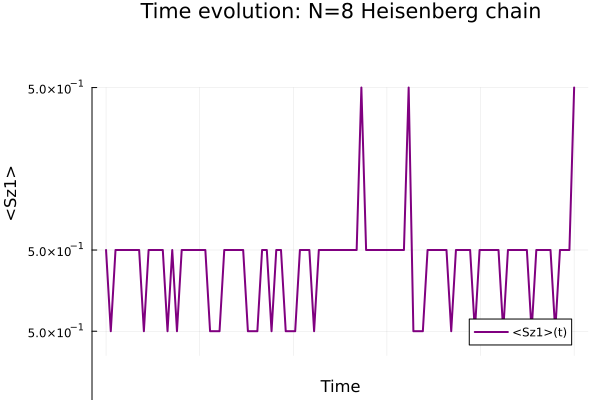

GKS: Possible loss of precision in routine SET_WINDOW


In [10]:
N   = 8
H8  = heisenberg_hamiltonian(N)
dim = 2^N

psi0      = zeros(ComplexF64, dim)
psi0[1]   = 1.0

I2s = sparse([1 0; 0 1] .+ 0.0)
Sz  = sparse([1 0; 0 -1] ./ 2.0)
Sz1 = foldl(kron, [j==1 ? Sz : I2s for j in 1:N])

times   = range(0, 5, length=100)
sz_vals = Float64[]

for t in times
    psi_t = expv(-im * t, H8, psi0)
    push!(sz_vals, real(psi_t' * Sz1 * psi_t))
end

plot(collect(times), sz_vals,
     linewidth=2, color=:purple,
     xlabel="Time", ylabel="<Sz1>",
     title="Time evolution: N=8 Heisenberg chain",
     label="<Sz1>(t)")

### Lindblad master equation (QuantumOptics.jl)

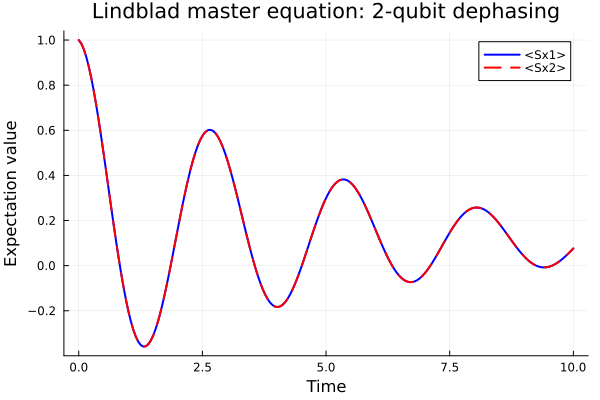

In [14]:
using QuantumOptics
using Plots

b = SpinBasis(1//2)

# Operators
Sx1 = tensor(sigmax(b), one(b))
Sx2 = tensor(one(b), sigmax(b))
Sz1 = tensor(sigmaz(b), one(b))
Sz2 = tensor(one(b), sigmaz(b))

# Hamiltonian
H_open = Sz1 * Sz2 + 0.3 * (Sx1 + Sx2)

# Initial state |+⟩ ⊗ |+⟩
psi_up   = basisstate(b, 1)
psi_down = basisstate(b, 2)
psi_plus = (psi_up + psi_down) / sqrt(2)
psi0     = tensor(psi_plus, psi_plus)

# Collapse operators (dephasing)
gamma = 0.1
c_ops = [sqrt(gamma) * Sz1, sqrt(gamma) * Sz2]

# Solve Lindblad master equation
tspan = collect(range(0, 10, length=200))
tout, rho_t = timeevolution.master(tspan, psi0, H_open, c_ops)

# Expectation values
ex1 = real.(expect(Sx1, rho_t))
ex2 = real.(expect(Sx2, rho_t))

# Plot
plot(tout, ex1,
     linewidth=2, color=:blue, label="<Sx1>",
     xlabel="Time", ylabel="Expectation value",
     title="Lindblad master equation: 2-qubit dephasing")
plot!(tout, ex2,
      linewidth=2, color=:red, linestyle=:dash, label="<Sx2>")

### Entanglement entropy via SVD

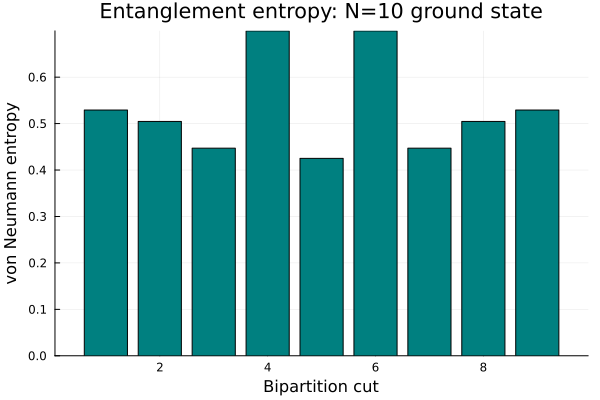

In [15]:
function entanglement_entropy(psi, N, cut)
    dA = 2^cut
    dB = 2^(N - cut)
    M  = reshape(psi, dA, dB)
    sv = svdvals(M)
    p  = abs2.(sv)
    p  = p[p .> 1e-14]
    return -sum(p .* log.(p))
end

N10 = 10
H10 = heisenberg_hamiltonian(N10)
_, evecs10, _ = eigsolve(H10, 2^N10, 1, :SR, ishermitian=true)
gs = evecs10[1]

cuts    = 1:N10-1
entropy = [entanglement_entropy(gs, N10, c) for c in cuts]

bar(cuts, entropy,
    color=:teal,
    xlabel="Bipartition cut",
    ylabel="von Neumann entropy",
    title="Entanglement entropy: N=10 ground state",
    legend=false)

### Final benchmark: all methods together

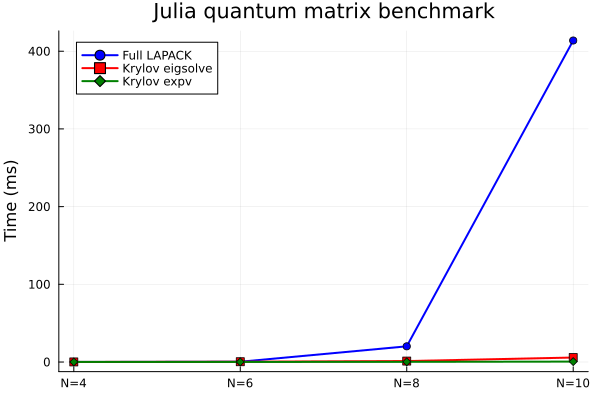

In [16]:
N_vals   = [4, 6, 8, 10]
t_lapack = Float64[]
t_kry    = Float64[]
t_exp    = Float64[]

for N in N_vals
    H   = heisenberg_hamiltonian(N)
    d   = 2^N
    psi = normalize(randn(ComplexF64, d))

    t1 = time_ns()
    eigvals(Hermitian(Matrix(H)))
    push!(t_lapack, (time_ns() - t1) / 1e6)

    t2 = time_ns()
    eigsolve(H, d, 4, :SR, ishermitian=true)
    push!(t_kry, (time_ns() - t2) / 1e6)

    t3 = time_ns()
    expv(-im * 1.0, H, psi)
    push!(t_exp, (time_ns() - t3) / 1e6)
end

labels_x = ["N=$n" for n in N_vals]

plot(labels_x, t_lapack,
     marker=:circle, linewidth=2, color=:blue,
     label="Full LAPACK", ylabel="Time (ms)",
     title="Julia quantum matrix benchmark")
plot!(labels_x, t_kry,
      marker=:square, linewidth=2, color=:red, label="Krylov eigsolve")
plot!(labels_x, t_exp,
      marker=:diamond, linewidth=2, color=:green, label="Krylov expv")